- **date** - дата продажи дома. 

- **price** - за сколько продали дом. 
- **bedrooms** - сколько спален в доме.  
- **bathrooms** - сколько ванных комнат. 
- **living_in_m2** - площадь жилой части квартиры в квадратных метрах.
- **nice_view** - есть ли красивый вид из окон (на парк, реку или город).
- **perfect_condition** - квартира в идеальном состоянии или нет.  
- **grade** - качество строительства и дизайна по шкале от 1 до 5. 
- **has_basement** - есть ли подвал. 
- **renovated** - была ли квартира отремонтирована.  
- **has_lavatory** - есть ли дополнительные маленькие санузлы (например, гостевой туалет).  
- **single_floor** - одноэтажная квартира или дом. Для некоторых это важно из-за удобства и безопасности.  
- **month** - месяц продажи.  
- **quartile_zone** - насколько дорогой район по сравнению с другими.

### 1. Импорт библиотек и изучение информации о данных

In [1]:
#автоматическая перезагрузка измененных модулей
%load_ext autoreload
%autoreload 2

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display
from side_lib import *
from visual import *
from phik import phik_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.float_format', '{:,.2f}'.format) 

In [3]:
#загрузка данных
data = pd.read_csv('df_train.csv')

In [4]:
#информация о данных
data_info(data)

'Первые строки'

,date,price,bedrooms,grade,has_basement,living_in_m2,renovated,nice_view,perfect_condition,real_bathrooms,has_lavatory,single_floor,month,quartile_zone
0,2014-05-15,"312,000.00",2,2,True,138.43,False,False,False,2,True,False,5,1
1,2014-11-14,"310,000.00",2,2,False,105.91,False,False,False,1,True,False,11,3
2,2014-12-24,"320,000.00",2,2,False,117.99,False,True,False,1,False,True,12,2
3,2015-02-22,"264,500.00",2,3,False,151.43,False,False,False,2,True,True,2,1
4,2015-01-06,"700,000.00",3,2,True,341.88,False,False,False,3,False,False,1,4


'Описание данных'

,price,bedrooms,grade,living_in_m2,real_bathrooms,month,quartile_zone
count,"13,603.00","13,603.00","13,603.00","13,603.00","13,603.00","13,603.00","13,603.00"
mean,"475,286.09",2.24,2.53,181.75,1.68,6.58,2.43
std,"207,323.21",0.68,0.97,67.92,0.63,3.13,1.07
min,"81,000.00",1.00,1.00,49.24,1.00,1.00,1.00
25%,"315,000.00",2.00,2.00,130.06,1.00,4.00,2.00
50%,"435,000.00",2.00,2.00,171.87,2.00,6.00,2.00
75%,"599,950.00",3.00,3.00,224.83,2.00,9.00,3.00
max,"1,155,000.00",3.00,5.00,391.12,3.00,12.00,4.00


'Базовая системная информация'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13603 entries, 0 to 13602
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               13603 non-null  object 
 1   price              13603 non-null  float64
 2   bedrooms           13603 non-null  int64  
 3   grade              13603 non-null  int64  
 4   has_basement       13603 non-null  bool   
 5   living_in_m2       13603 non-null  float64
 6   renovated          13603 non-null  bool   
 7   nice_view          13603 non-null  bool   
 8   perfect_condition  13603 non-null  bool   
 9   real_bathrooms     13603 non-null  int64  
 10  has_lavatory       13603 non-null  bool   
 11  single_floor       13603 non-null  bool   
 12  month              13603 non-null  int64  
 13  quartile_zone      13603 non-null  int64  
dtypes: bool(6), float64(2), int64(5), object(1)
memory usage: 930.0+ KB


None

Всего 13603 строки и 14 столбцов

In [5]:
#информация о дубликатах
mis_dup_info(data)

,total,missing,percent_missing,duplicated,percent_duplicated
date,13603,0,0.0%,2,0.015%
price,13603,0,0.0%,2,0.015%
bedrooms,13603,0,0.0%,2,0.015%
grade,13603,0,0.0%,2,0.015%
has_basement,13603,0,0.0%,2,0.015%
living_in_m2,13603,0,0.0%,2,0.015%
renovated,13603,0,0.0%,2,0.015%
nice_view,13603,0,0.0%,2,0.015%
perfect_condition,13603,0,0.0%,2,0.015%
real_bathrooms,13603,0,0.0%,2,0.015%


Нет пропущенных значений.  
Всего 2 дубликата, на данные они никак не повляют.

### 2. Признаки с датами

`date`

Преобразуем столбец чтобы визуализировать.

In [6]:
#преобразование столбца date в формат datetime
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')

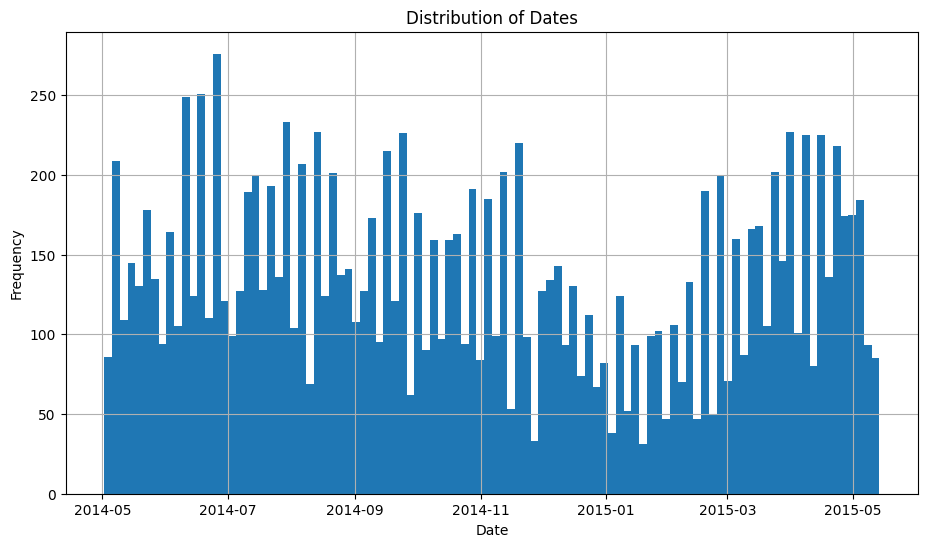

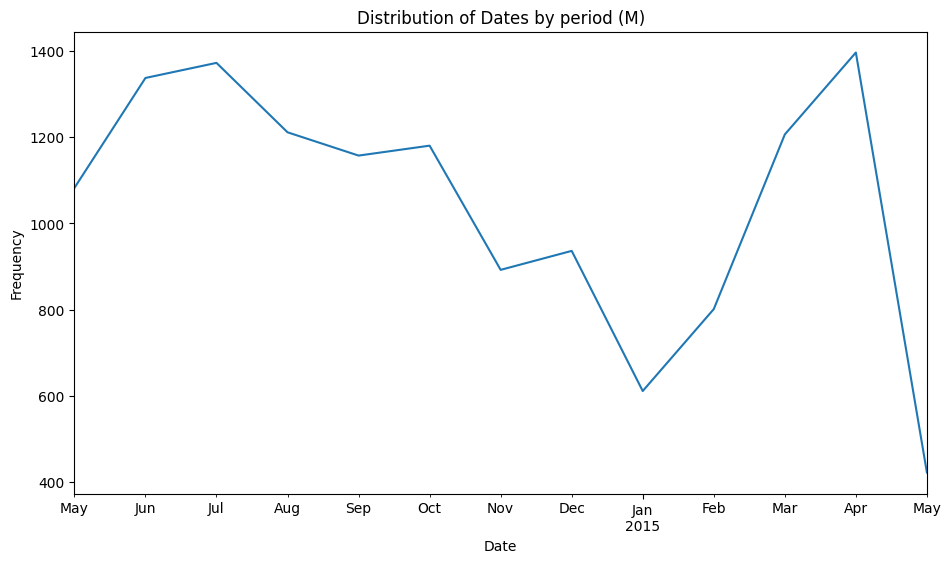

In [7]:
date_info(data, 'date')

Всего представлены данные с мая 2014 по май 2015.  
Больше всего данных за июнь, июль - 2014 года, и апрель 2015.

### 3. Количественные признаки 

`price`

count      13,603.00
mean      475,286.09
std       207,323.21
min        81,000.00
25%       315,000.00
50%       435,000.00
75%       599,950.00
max     1,155,000.00
Name: price, dtype: float64

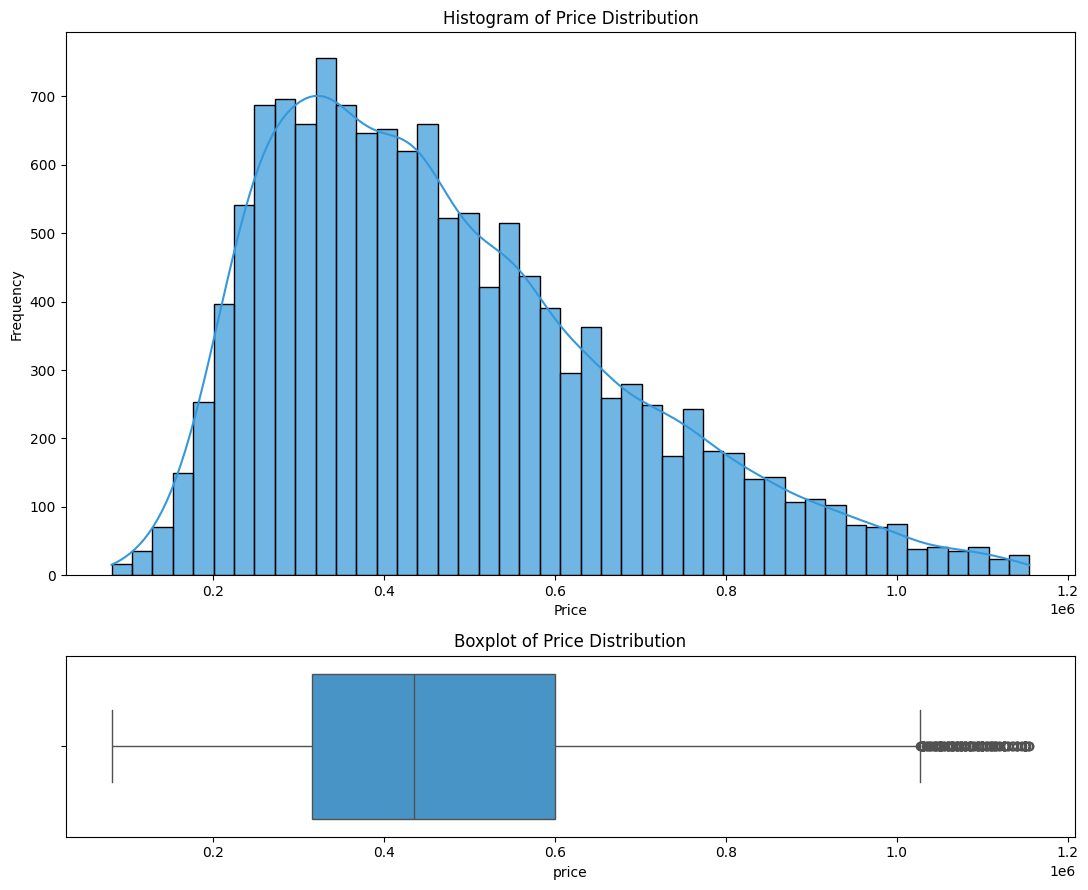

In [62]:
kol_info(data['price'], title='Price Distribution', y_title='Frequency', x_title='Price')

На графике видно правостороннее скошенное распределение, с пиком в районе 350000.  
Выбросы не сильно дальше правого уса.

In [33]:
data.loc[data['price'] > 1000000].describe()

,date,price,bedrooms,grade,living_in_m2,real_bathrooms,month,quartile_zone
count,226,226.00,226.00,226.00,226.00,226.00,226.00,226.00
mean,2014-10-25 19:45:07.964601856,"1,073,286.42",2.68,4.00,288.32,2.33,6.63,3.56
min,2014-05-06 00:00:00,"1,001,000.00",1.00,1.00,133.78,1.00,1.00,1.00
25%,2014-07-03 00:00:00,"1,038,000.00",2.00,3.00,245.50,2.00,4.00,3.00
50%,2014-10-15 00:00:00,"1,070,000.00",3.00,4.00,286.14,2.00,6.00,4.00
75%,2015-02-19 12:00:00,"1,102,992.50",3.00,5.00,334.45,3.00,9.00,4.00
max,2015-05-05 00:00:00,"1,155,000.00",3.00,5.00,391.12,3.00,12.00,4.00
std,NaN,"43,882.93",0.51,0.93,59.23,0.63,3.07,0.72


Значения выбросов в столбце price показывает высокие показатели по каждой категрии.

`living_in_m2`

count   13,603.00
mean       181.75
std         67.92
min         49.24
25%        130.06
50%        171.87
75%        224.83
max        391.12
Name: living_in_m2, dtype: float64

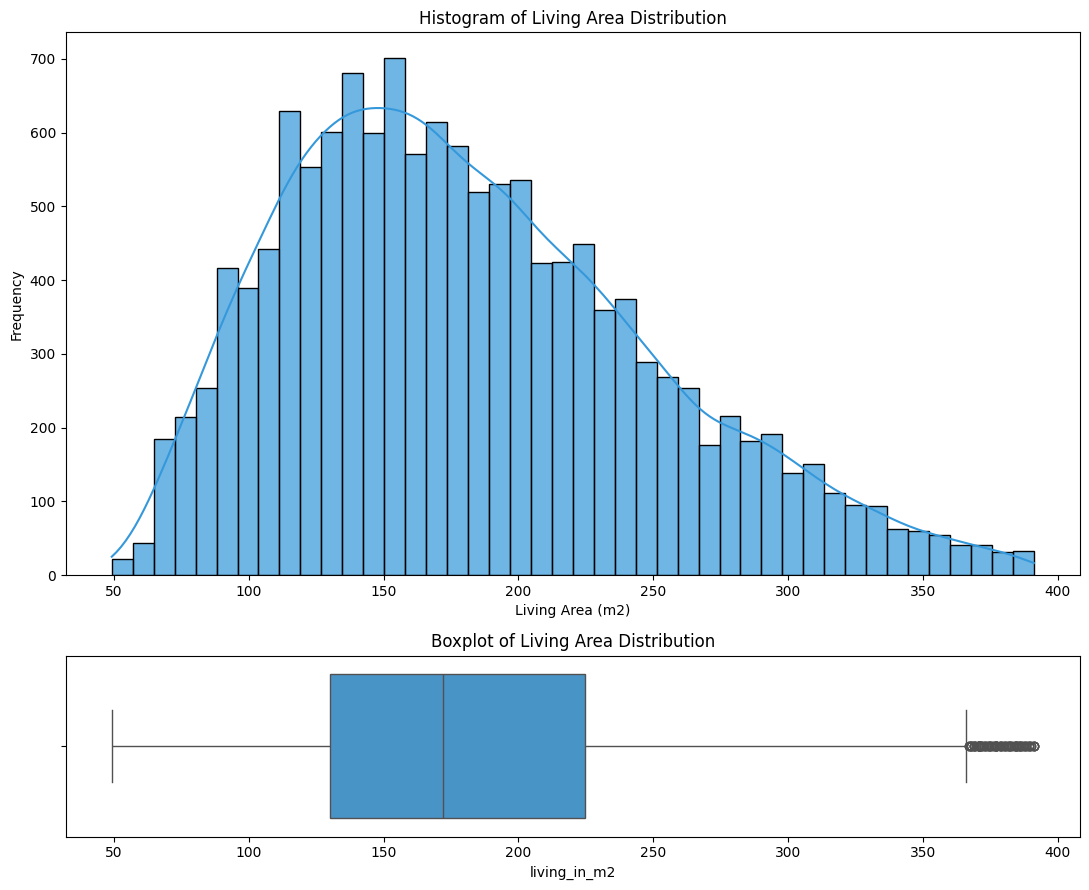

In [9]:
kol_info(data['living_in_m2'], title='Living Area Distribution', y_title='Frequency', x_title='Living Area (m2)')

Пик находится в районе 150 кв.м. правостороннее скошенное распределение

### 4. Категориальные признаки

`bedrooms`

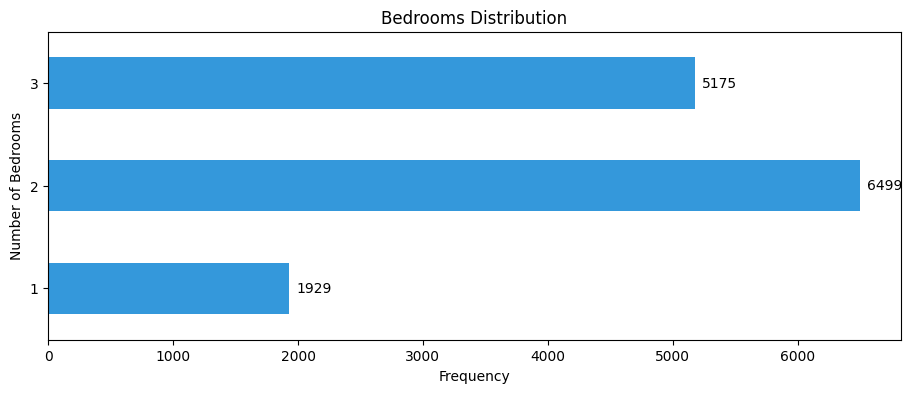

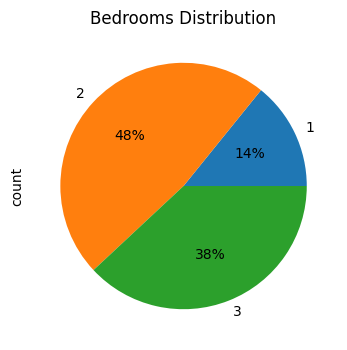

'Средняя цена по категориям:'

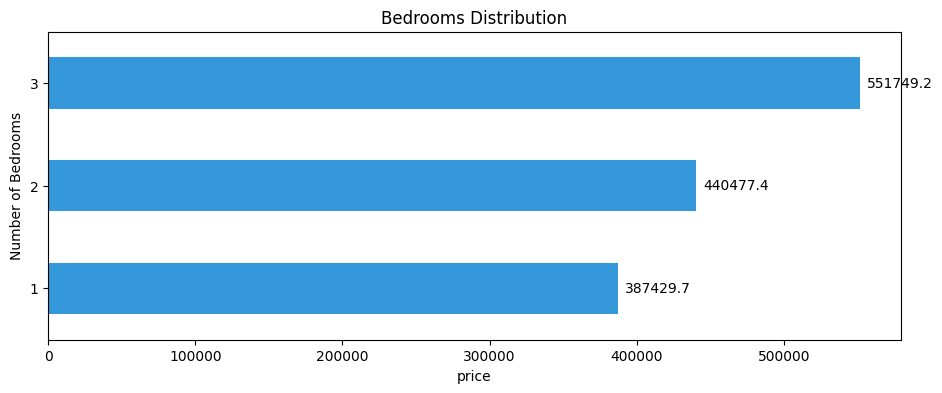

In [10]:
cat_info(data, 'bedrooms', title='Bedrooms Distribution', y_title='Number of Bedrooms', x_title='Frequency', index_sort=True)

Больше всего двуспальных домов, цена растет с количеством спален.

`grade`

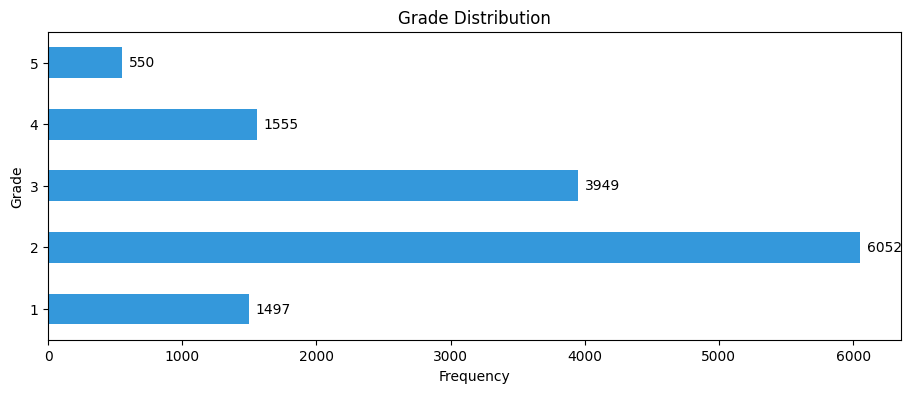

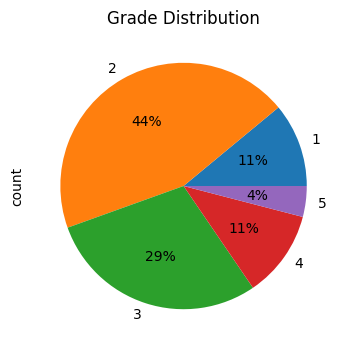

'Средняя цена по категориям:'

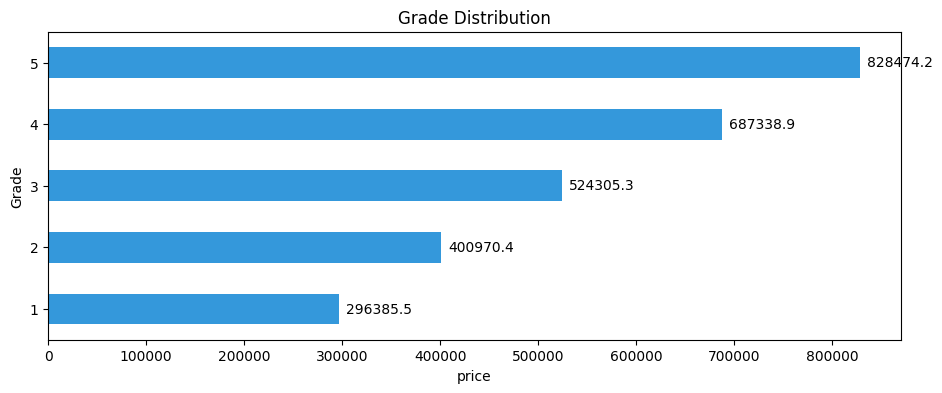

In [11]:
cat_info(data, 'grade', title='Grade Distribution', y_title='Grade', x_title='Frequency', index_sort=True)

Больше всего данных по уровню качества 2.  
Чем выше уровень качества, тем выше цена.

`has_basement`

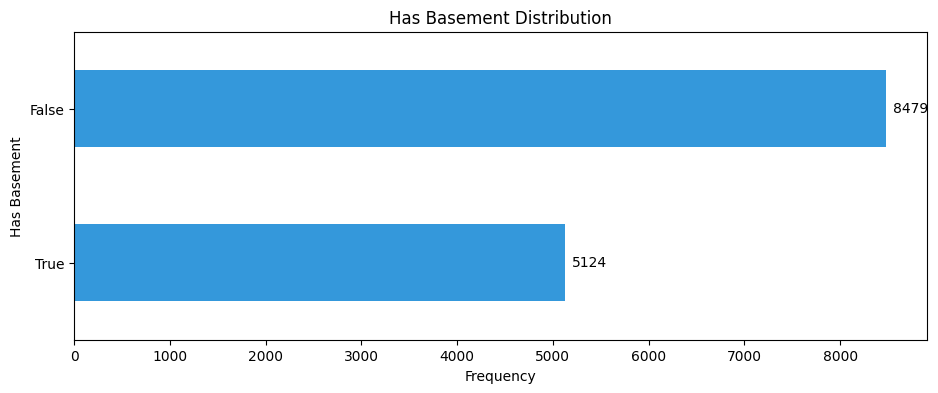

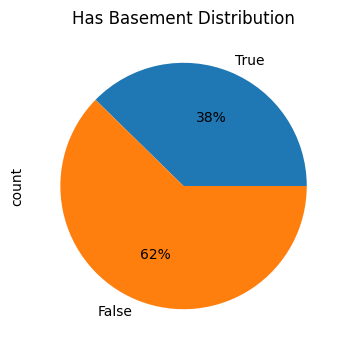

'Средняя цена по категориям:'

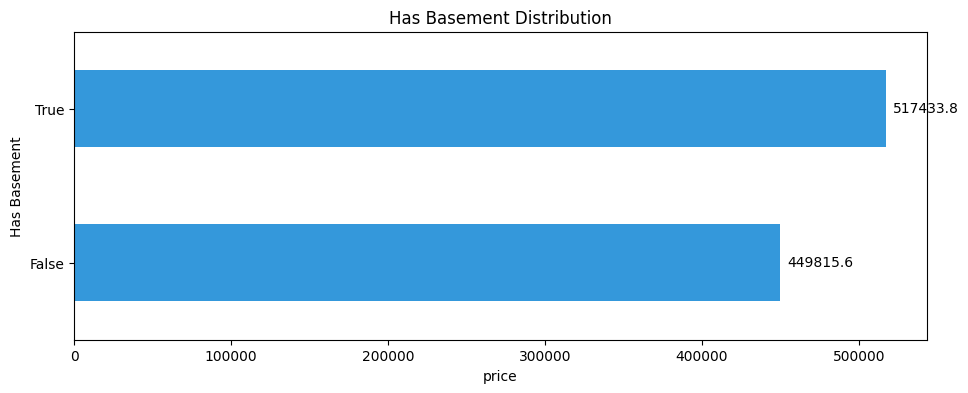

In [12]:
cat_info(data, 'has_basement', title='Has Basement Distribution', y_title='Has Basement', x_title='Frequency')

Домов с без подвала больше.  
Дома с подвалом стоят дороже 

`renovated`

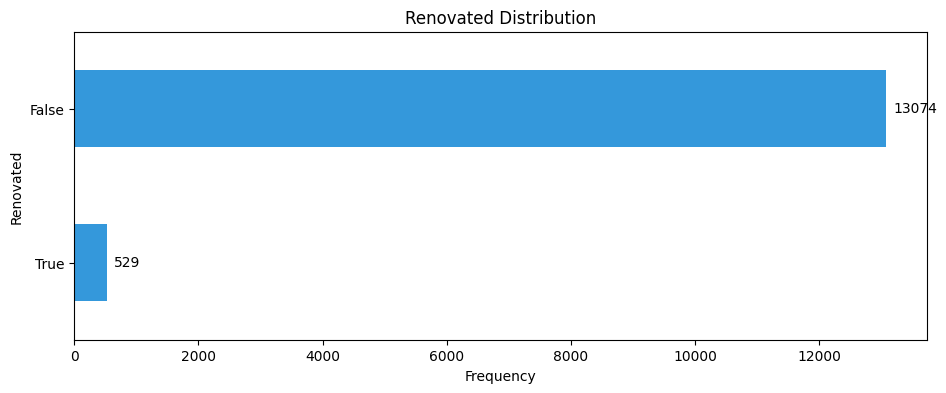

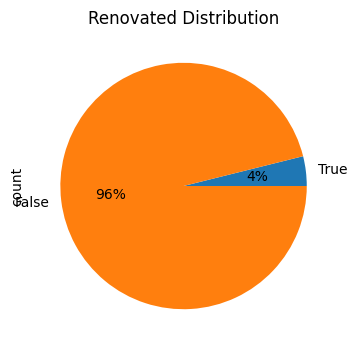

'Средняя цена по категориям:'

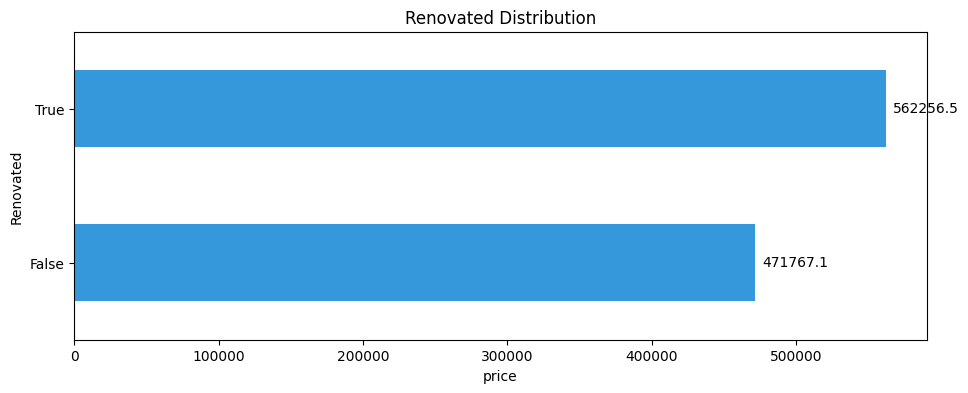

In [13]:
cat_info(data, 'renovated', title='Renovated Distribution', y_title='Renovated', x_title='Frequency')

Отремонтированные дома - более дорогие по средней цене, но их сильно меньше

`nice_view`

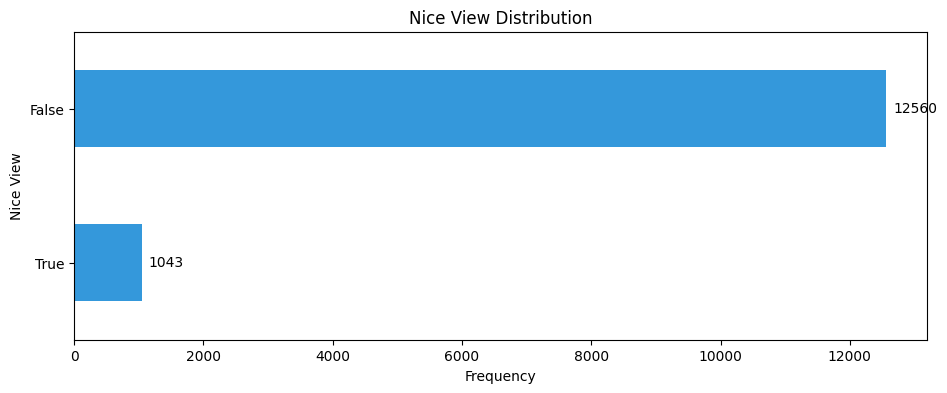

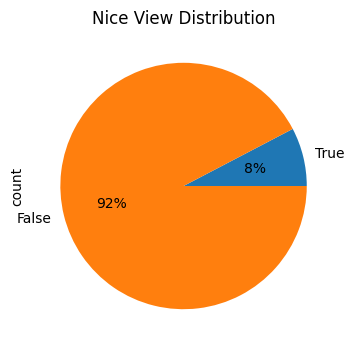

'Средняя цена по категориям:'

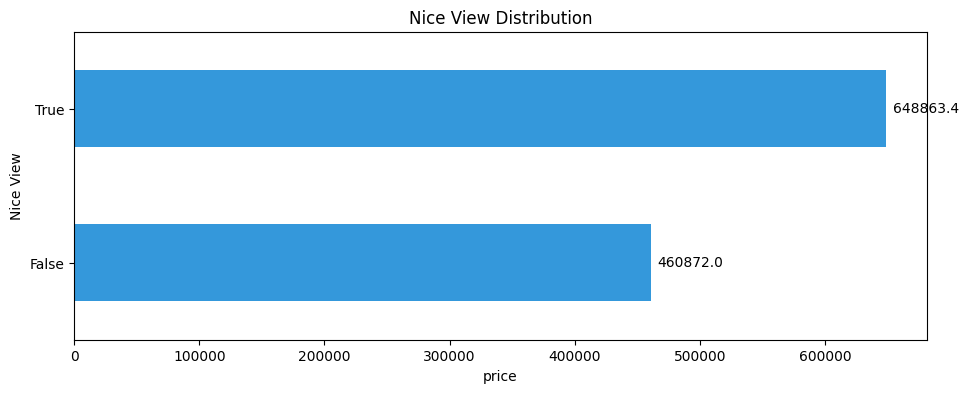

In [14]:
cat_info(data, 'nice_view', title='Nice View Distribution', y_title='Nice View', x_title='Frequency')

Домов с хорошим видом немного, но они дороже остальных.

`perfect_condition`

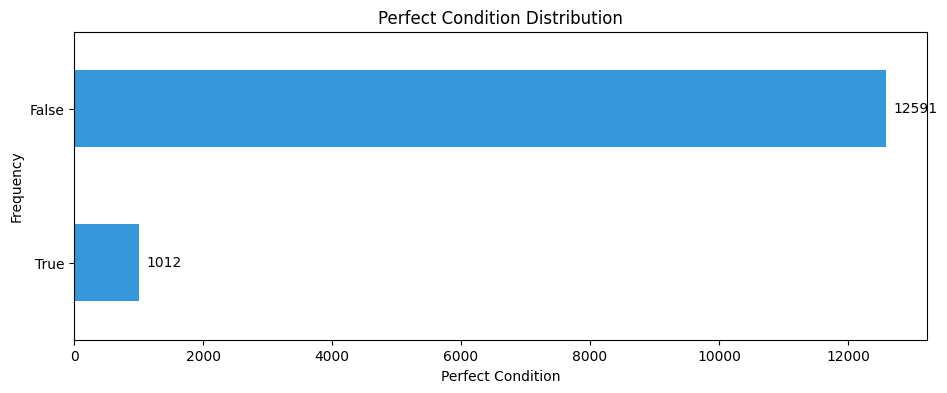

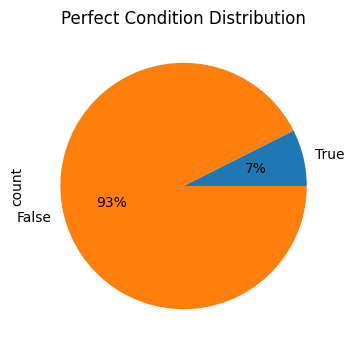

'Средняя цена по категориям:'

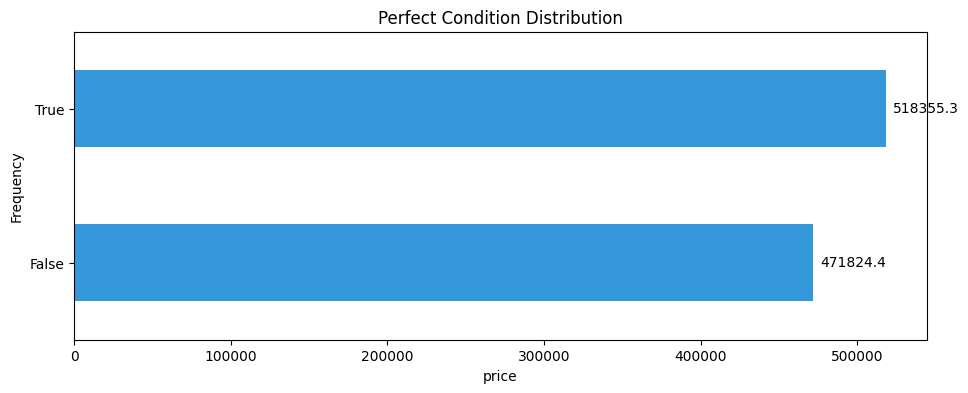

In [15]:
cat_info(data, 'perfect_condition', title='Perfect Condition Distribution', y_title='Frequency', x_title='Perfect Condition')

Домов в идеальном состоянии сильно меньше и стоят они в среднем дороже

`real_bathrooms`

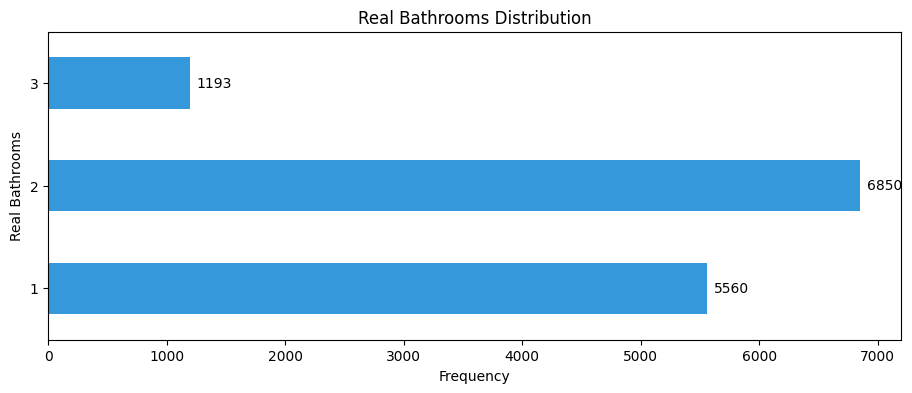

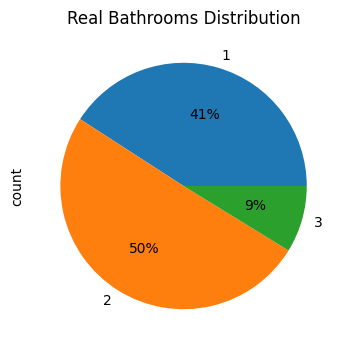

'Средняя цена по категориям:'

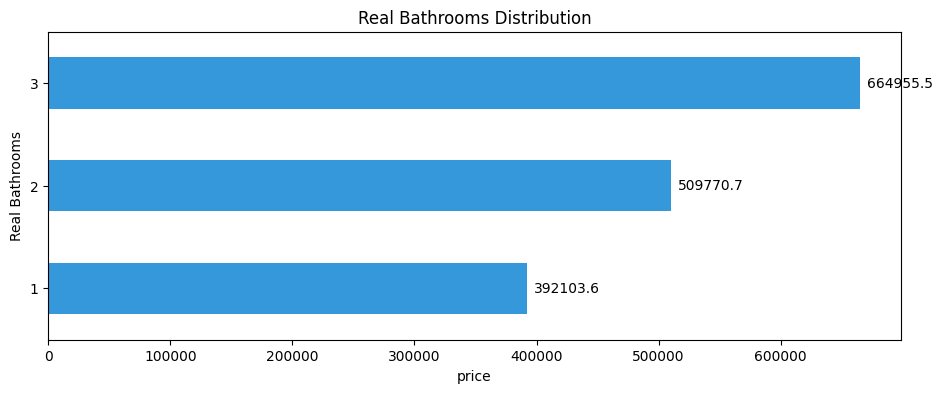

In [16]:
cat_info(data, 'real_bathrooms', title='Real Bathrooms Distribution', y_title='Real Bathrooms', x_title='Frequency', index_sort=True)

Домов с 2 санузлами больше всего, цена растет с количеством санузлов.

`has_lavatory`

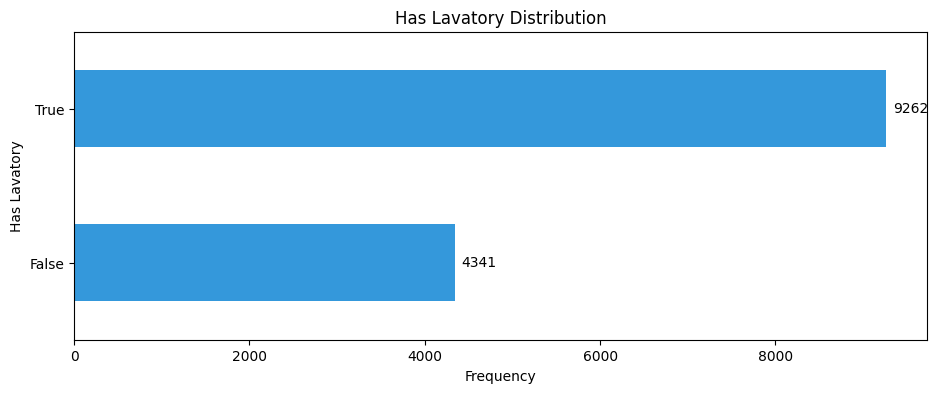

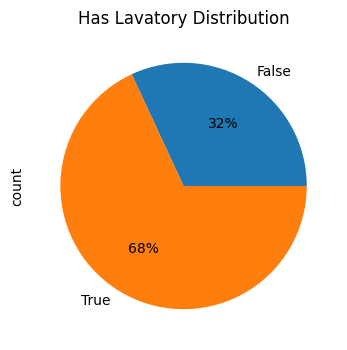

'Средняя цена по категориям:'

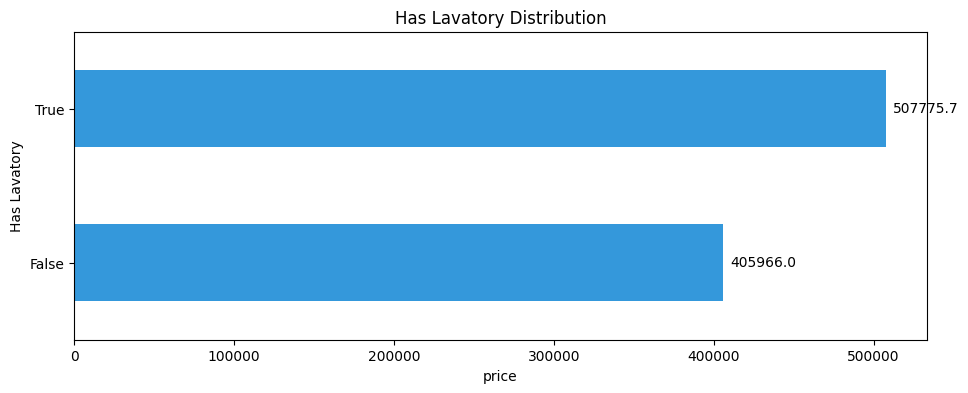

In [17]:
cat_info(data, 'has_lavatory', title='Has Lavatory Distribution', y_title='Has Lavatory', x_title='Frequency')

Домов с дополнительными-гостевыми санузлами больше в два раза, и цена их тоже больше.

`single_floor`

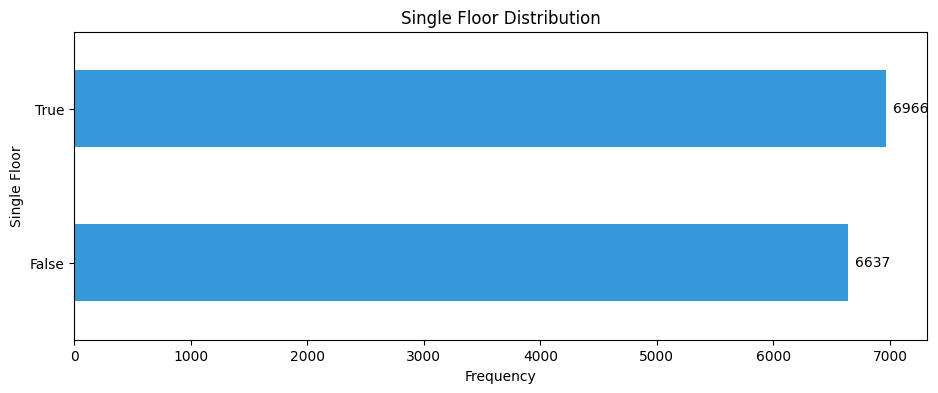

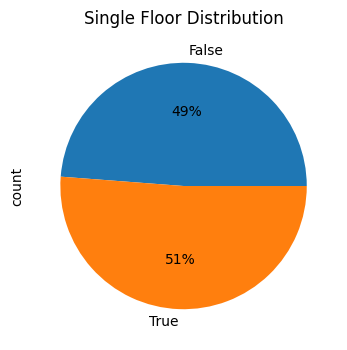

'Средняя цена по категориям:'

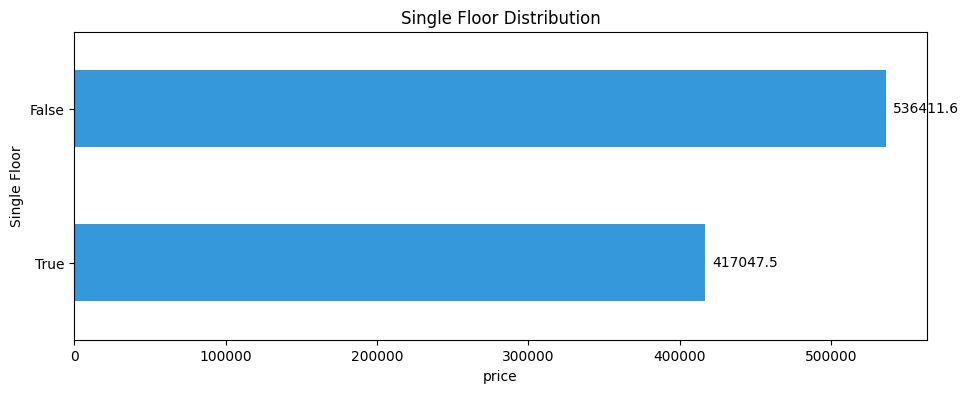

In [18]:
cat_info(data, 'single_floor', title='Single Floor Distribution', y_title='Single Floor', x_title='Frequency')

Количество домов с одним этажом и больше чем одним примерно одинаково.  
 Средняя цена домов с одним этажом ниже, чем у домов с несколькими этажами.

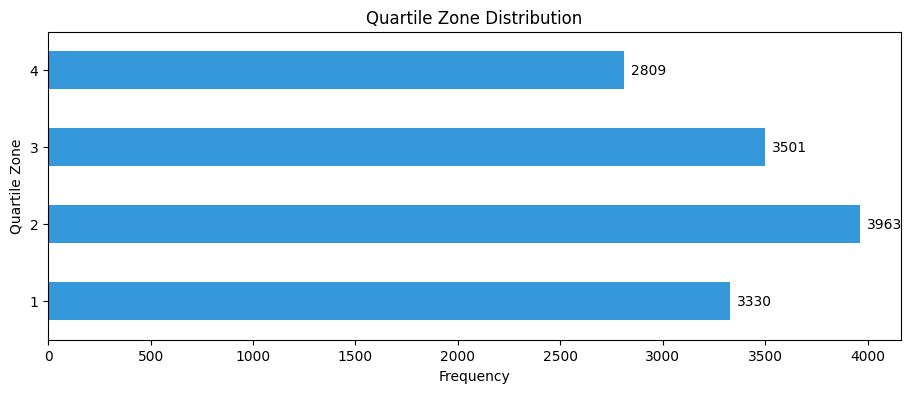

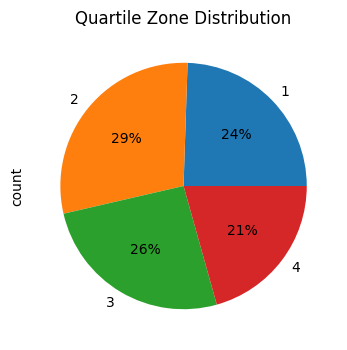

'Средняя цена по категориям:'

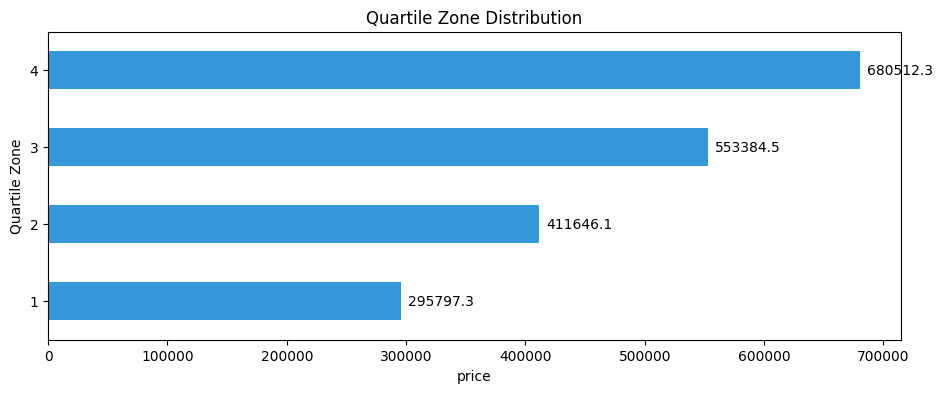

In [19]:
cat_info(data, 'quartile_zone', title='Quartile Zone Distribution', y_title='Quartile Zone', x_title='Frequency', index_sort=True)

Чаще всего качество района равно 2 из 4, чем выше качество района, тем, соотвественно дороже дом.

### 5. Корреляция и Мультиколлинеарность

В связи с наличием категориальных признаков в данных, для оценки корреляции используется метод Phik.

interval columns not set, guessing: ['price', 'bedrooms', 'grade', 'living_in_m2', 'real_bathrooms', 'month', 'quartile_zone']


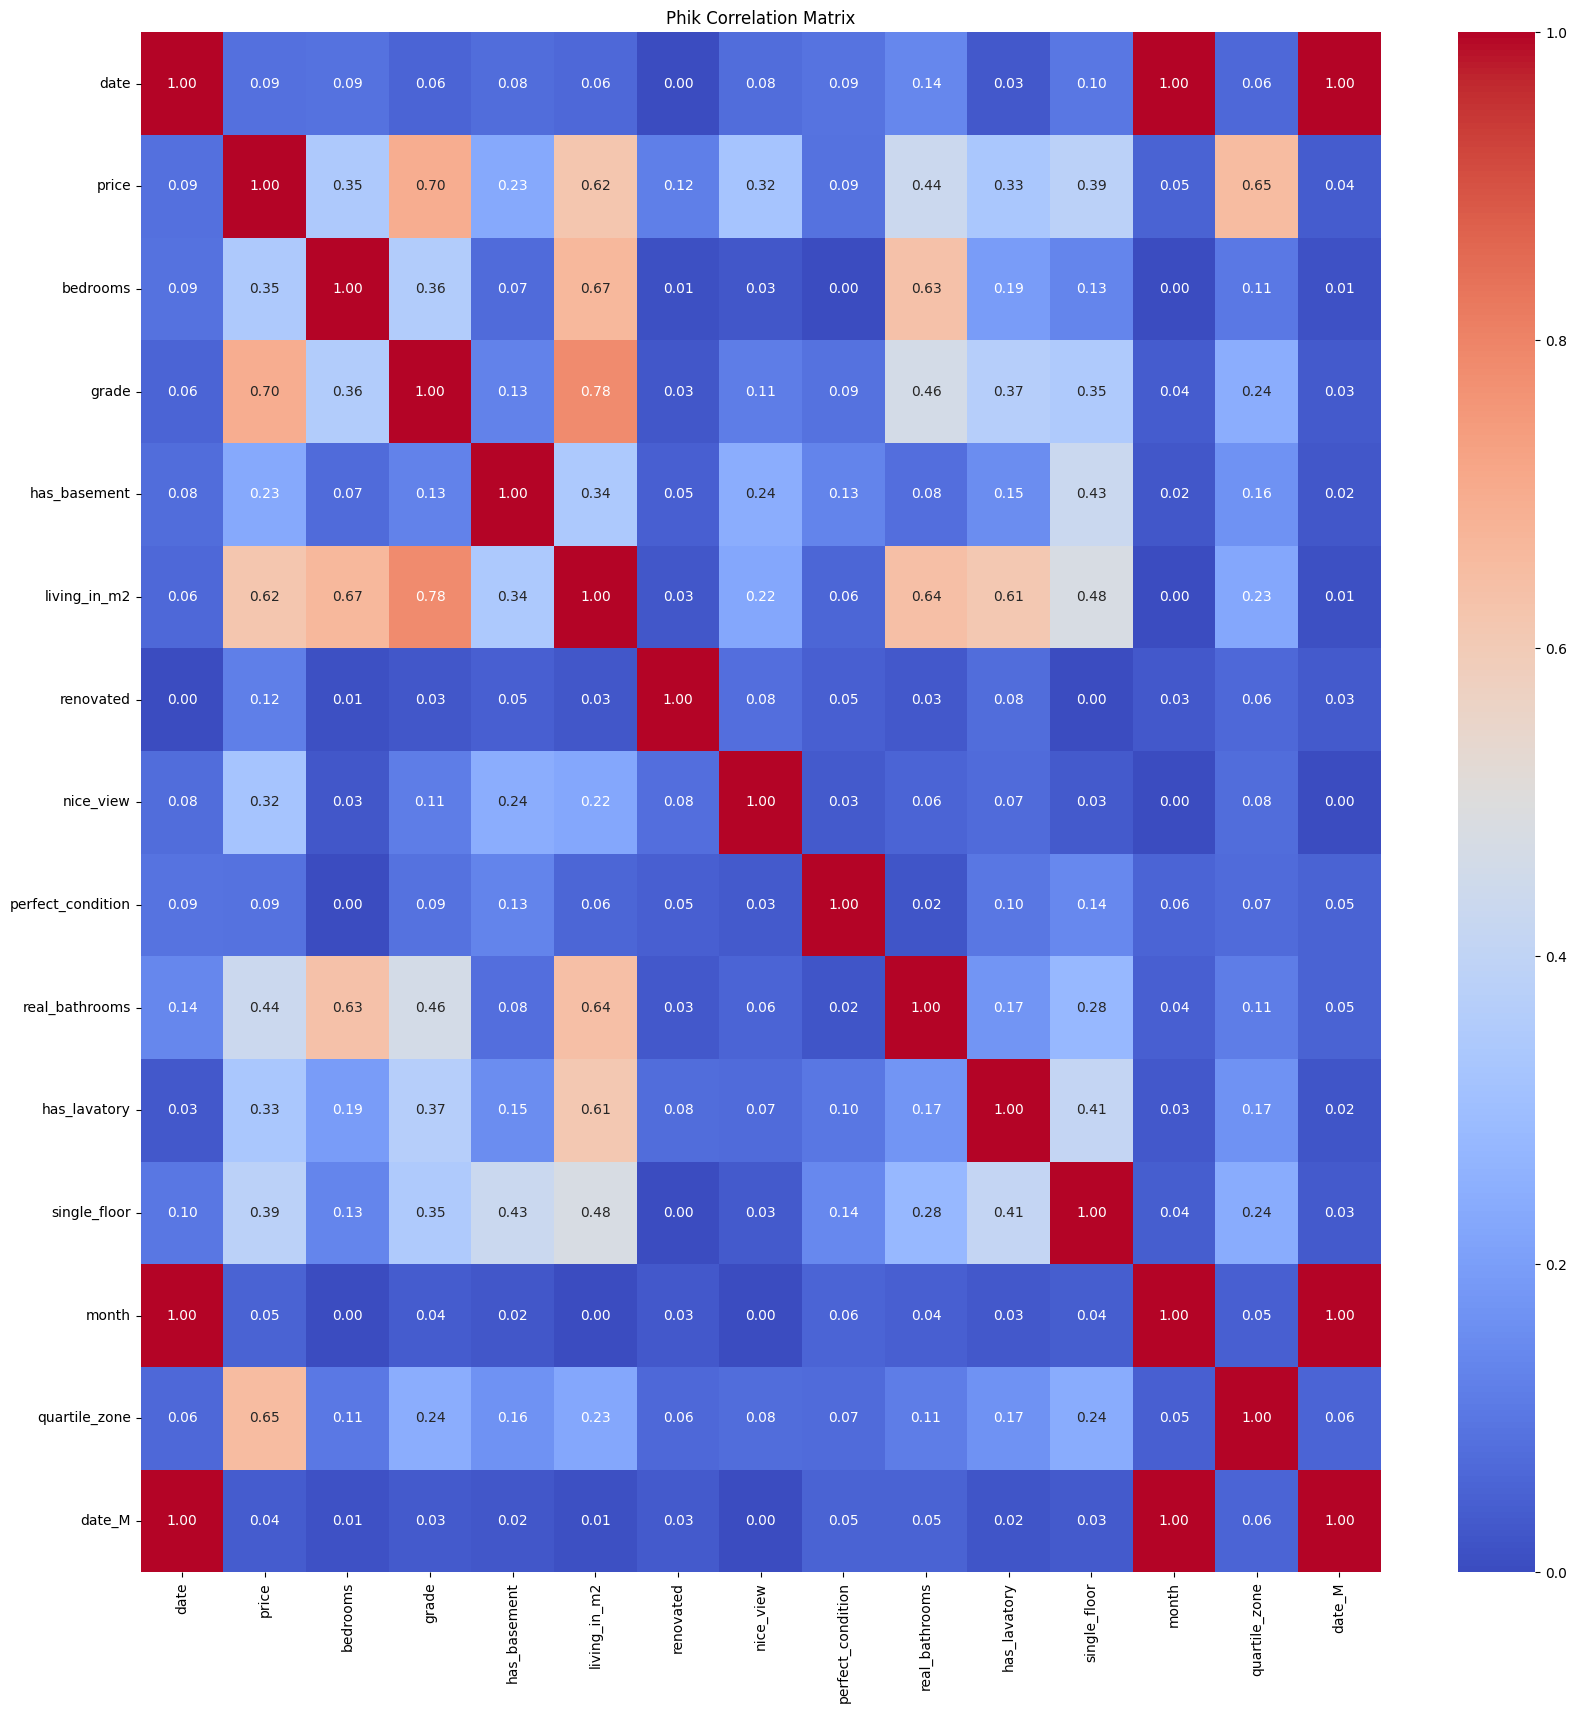

In [28]:
corr_phik = phik_matrix(data)
plt.figure(figsize=(20,20))
sns.heatmap(corr_phik, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Phik Correlation Matrix')
plt.show()

/Users/dalgat/Documents/project/visual.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  #гистограмма
/Users/dalgat/Documents/project/visual.py:19: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax[0].set_ylabel(y_title)


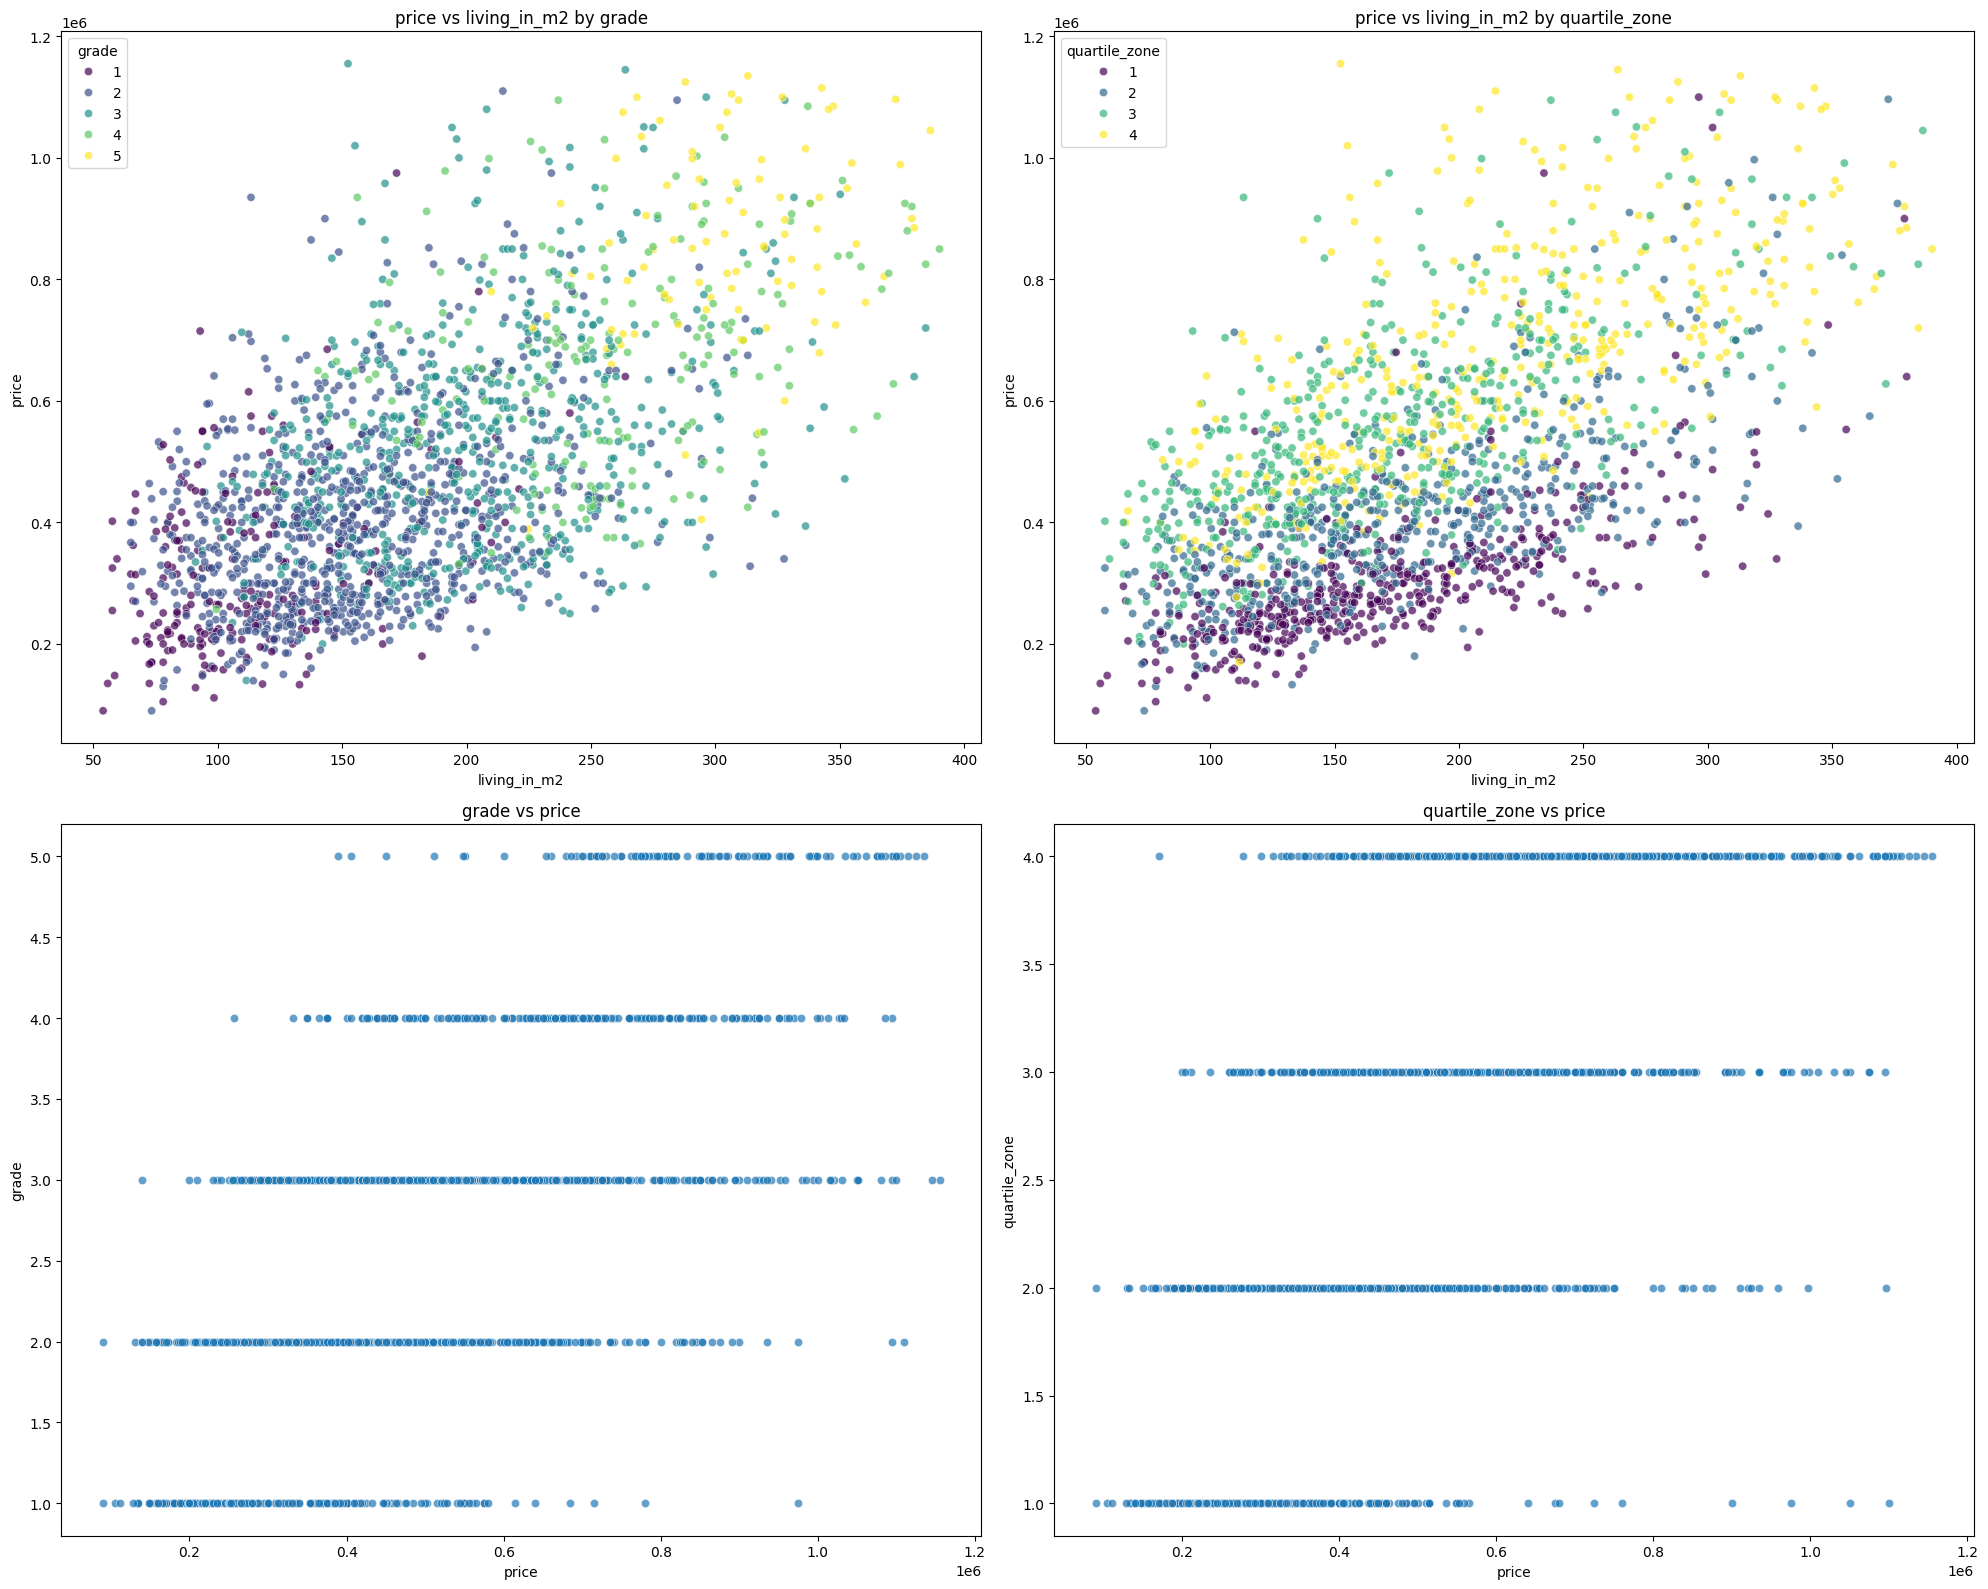

In [56]:
four_scatter_horizontal(data, 'living_in_m2', 'price', 'grade', 'quartile_zone', is_sample=True, sample_size=2000)

Проверим так же мультиколлинеарность с помощью VIF (Variance Inflation Factor) для числовых признаков.

In [60]:
#расчет VIF для числовых столбцов
numeric_data = data.select_dtypes(include=[int, float]).drop(columns=['price'])
vif_df = calculate_vif(numeric_data)
display(vif_df.sort_values(by='VIF', ascending=False))


,feature,VIF
2,living_in_m2,23.81
1,grade,16.45
0,bedrooms,14.48
3,real_bathrooms,12.94
5,quartile_zone,5.93
4,month,4.42


Наблюдается сильная мультиколиниарность в столбцах living_in_m2, grade, bedrooms, real_bathrooms.